# Quadruple tank: the infinite horizon vs a long finite horizon

The model is the canonical declared quadruple tank from
[`models/quad_tank.py`](models/quad_tank.py): Johansson's four-tank process
in its nonminimum-phase configuration, see the module for its construction.
Two cases of the same model. Case 1 runs five sampling steps (h = 10 s) with
the infinite-horizon terminal segment (`drto.infinite_horizon`) carrying the
tail, which deactivates the declared terminal cost since the tail owns the
cost-to-go. Case 2 runs fifty steps of plain finite horizon with the
terminal cost live.

## Case 1: five samples plus the infinite-horizon tail

In [1]:
import pyomo.environ as pyo
import pyomo_pounce  # registers pounce with the native factory
from pyomo.contrib.solver.common.factory import SolverFactory
import drto
from models.quad_tank import quad_tank
from drto import plot_states, plot_controls, plot_stage_cost

m1 = quad_tank(N=5, h=10)
pyo.TransformationFactory("dae.collocation").apply_to(m1, wrt=m1.t, nfe=5, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*h) = tau_11; pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
pyo.TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
SolverFactory("pounce").solve(m1, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.10.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmp4zjdg5vn\unknownxsswigjx.nl...
Parsed

   5  2.9369376e+02 1.40e-04 2.44e-07   -3.8 4.95e-02      - 1.00e+00 1.00e+00f  1
   6  2.9368166e+02 9.80e-09 1.85e-11   -5.7 4.87e-04      - 1.00e+00 1.00e+00h  1
   7  2.9368151e+02 1.12e-12 4.26e-14   -8.6 4.30e-06      - 1.00e+00 1.00e+00h  1


Number of Iterations....: 7

                                   (scaled)                 (unscaled)
Objective...............:   2.9368151239398216e+01    2.9368151239398213e+02
Dual infeasibility......:   4.2632564145606011e-14    4.2632564145606011e-13
Constraint violation....:   1.1226575225009583e-12    1.1226575225009583e-12
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5059766606256919e-09    2.5059766606256919e-08
Overall NLP error.......:   2.5059766606256919e-09    2.5059766606256919e-08


Number of objective function evaluations             = 9
Number of objective gradient evaluations             = 8
Number of equality constraint evaluations            = 9
Number of ineq

In [2]:
drto.info(m1)

<drto registry>
states: 4, controls: 2
declarations:
  horizon: t (ContinuousSet, 16 points)
  states: x1 (free), x2 (free), x3 (free), x4 (free)
  dynamics: dx1[t]  ==  - a1/A1*sqrt(2*g*x1[t]) + a3/A1*sqrt(2*g*x3[t]) + gamma/A1*u1[t]  for t in t
  dynamics: dx2[t]  ==  - a2/A2*sqrt(2*g*x2[t]) + a4/A2*sqrt(2*g*x4[t]) + gamma/A2*u2[t]  for t in t
  dynamics: dx3[t]  ==  - a3/A3*sqrt(2*g*x3[t]) + (1 - gamma)/A3*u2[t]  for t in t
  dynamics: dx4[t]  ==  - a4/A4*sqrt(2*g*x4[t]) + (1 - gamma)/A4*u1[t]  for t in t
  controls: u1 (piecewise_constant, free), u2 (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  (x1[t] - x1_ss)**2 + (x2[t] - x2_ss)**2 + (x3[t] - x3_ss)**2 + (x4[t] - x4_ss)**2 + (u1[t] - u1_ss)**2 + (u2[t] - u2_ss)**2  for t in sorted(t)[:-1]
  terminal cost: term  ==  (x1[50] - x1_ss)**2 + (x2[50] - x2_ss)**2 + (x3[50] - x3_ss)**2 + (x4[50] - x4_ss)**2
  initial conditions: x1[0]  ==  x1_hat
  initial conditions: x2[0]  ==  x2_hat
  initial conditions: x3[0]  ==  x3_hat
  initial conditions: x4[0]  ==  x4_hat
  steady-state targets: x1_ss (of x1), x2_ss (of x2), x3_ss (of x3), x4_ss (of x4)
  steady-state control targets: u1_ss (of u1), u2_ss (of u2)
transformations:
  drto.infinite_horizon: segment=3 elements x 5 Legendre points, beta=1.2, gamma=0.00156383, profile=collocation, horizon=kept, infinite tail appended, terminal_cost=terminal deactivated (the tail owns it), terminal=soft pin z(tau=1)=z_s on 4 states, mu=1000.0
  drto.parameterize: profiles=u1 (piecewise_constant), u2 (piecewise_constant)
  drto.build_objective: objective=sum of 36 weighted cost terms

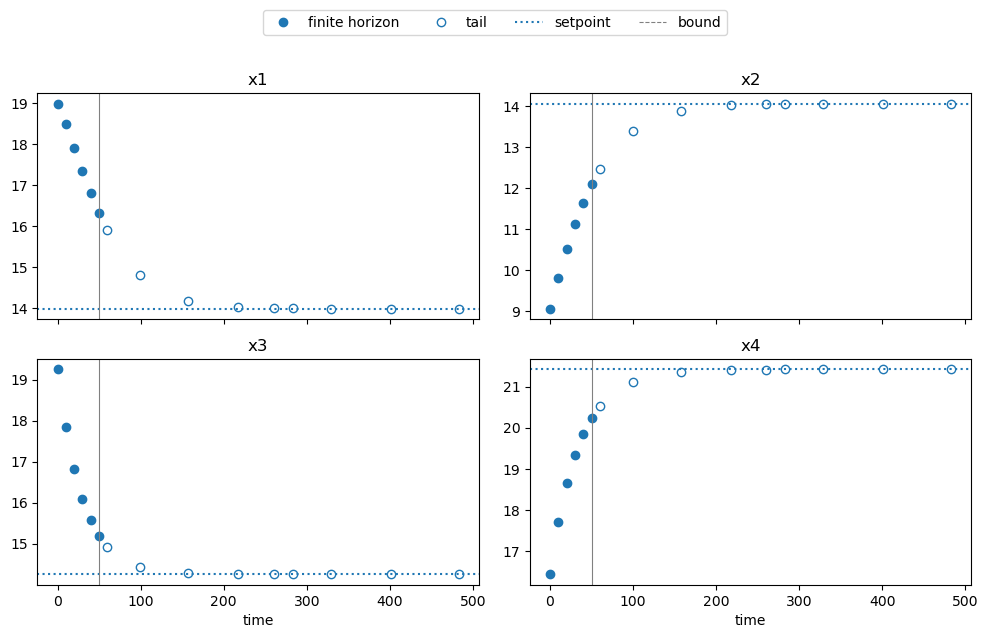

In [3]:
plot_states(m1, t_max=500);

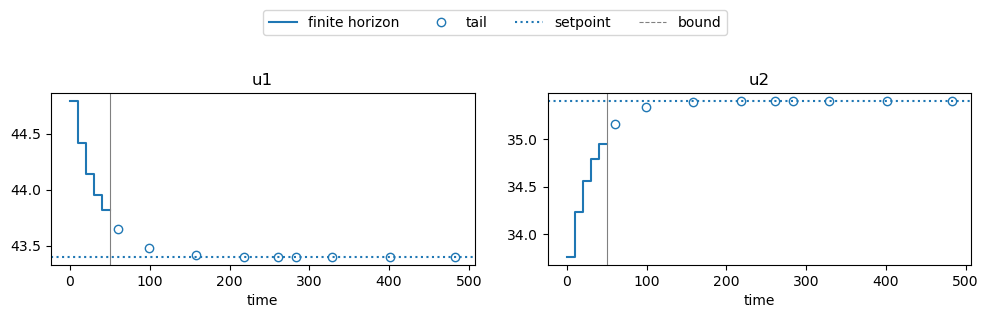

In [4]:
plot_controls(m1, t_max=500);

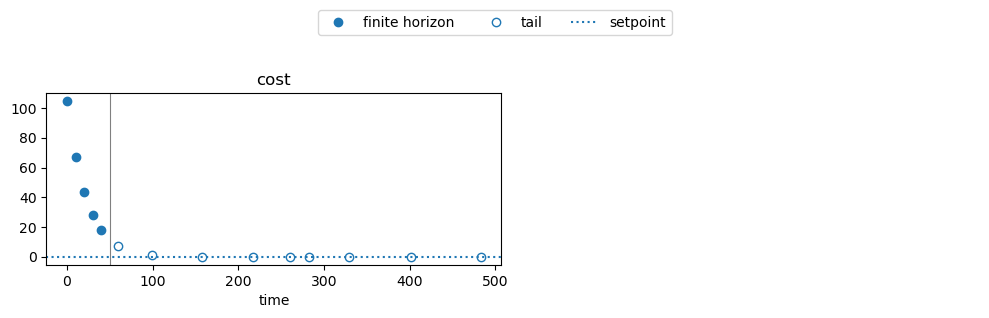

In [5]:
plot_stage_cost(m1, t_max=500);

## Case 2: fifty samples, finite horizon with the terminal cost

In [6]:
m2 = quad_tank(N=50, h=10)
pyo.TransformationFactory("dae.collocation").apply_to(m2, wrt=m2.t, nfe=50, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.parameterize").apply_to(m2)
drto.build_objective(m2)
SolverFactory("pounce").solve(m2, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.10.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpg9vymh4b\unknownz5qs1jet.nl...
Parsed

   5  2.9470317e+02 2.13e-10 2.39e-12   -5.7 3.97e-05      - 1.00e+00 1.00e+00h  1
   6  2.9470317e+02 4.26e-14 7.12e-15   -8.6 4.52e-07      - 1.00e+00 1.00e+00h  1


Number of Iterations....: 6

                                   (scaled)                 (unscaled)
Objective...............:   2.9470317386727942e+02    2.9470317386727942e+02
Dual infeasibility......:   7.1233463396001666e-15    7.1233463396001666e-15
Constraint violation....:   4.2632564145606011e-14    4.2632564145606011e-14
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5059238192358572e-09    2.5059238192358572e-09
Overall NLP error.......:   2.5059238192358572e-09    2.5059238192358572e-09


Number of objective function evaluations             = 8
Number of objective gradient evaluations             = 7
Number of equality constraint evaluations            = 8
Number of inequality constraint evaluations          = 8
Number of equality constraint Jacobian e

In [7]:
drto.info(m2)

<drto registry>
states: 4, controls: 2
declarations:
  horizon: t (ContinuousSet, 151 points)
  states: x1 (free), x2 (free), x3 (free), x4 (free)
  dynamics: dx1[t]  ==  - a1/A1*sqrt(2*g*x1[t]) + a3/A1*sqrt(2*g*x3[t]) + gamma/A1*u1[t]  for t in t
  dynamics: dx2[t]  ==  - a2/A2*sqrt(2*g*x2[t]) + a4/A2*sqrt(2*g*x4[t]) + gamma/A2*u2[t]  for t in t
  dynamics: dx3[t]  ==  - a3/A3*sqrt(2*g*x3[t]) + (1 - gamma)/A3*u2[t]  for t in t
  dynamics: dx4[t]  ==  - a4/A4*sqrt(2*g*x4[t]) + (1 - gamma)/A4*u1[t]  for t in t
  controls: u1 (piecewise_constant, free), u2 (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  (x1[t] - x1_ss)**2 + (x2[t] - x2_ss)**2 + (x3[t] - x3_ss)**2 + (x4[t] - x4_ss)**2 + (u1[t] - u1_ss)**2 + (u2[t] - u2_ss)**2  for t in sorted(t)[:-1]
  terminal cost: term  ==  (x1[500] - x1_ss)**2 + (x2[500] - x2_ss)**2 + (x3[500] - x3_ss)**2 + (x4[500] - x4_ss)**2
  initial conditions: x1[0]  ==  x1_hat
  initial conditions: x2[0]  ==  x2_hat
  initial conditions: x3[0]  ==  x3_hat
  initial conditions: x4[0]  ==  x4_hat
  steady-state targets: x1_ss (of x1), x2_ss (of x2), x3_ss (of x3), x4_ss (of x4)
  steady-state control targets: u1_ss (of u1), u2_ss (of u2)
transformations:
  drto.parameterize: profiles=u1 (piecewise_constant), u2 (piecewise_constant)
  drto.build_objective: objective=sum of 51 weighted cost terms

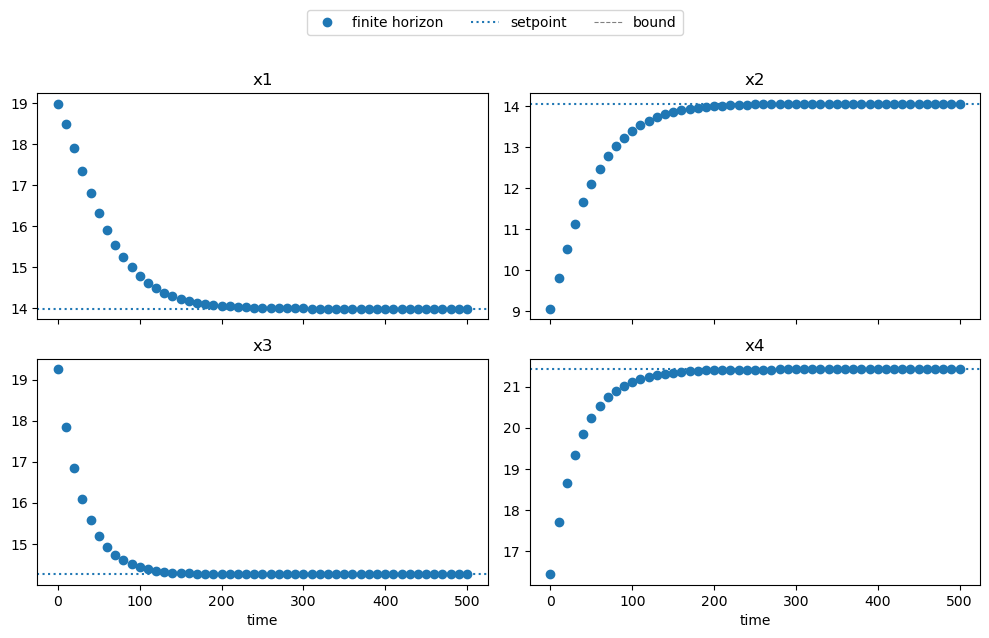

In [8]:
plot_states(m2, t_max=500);

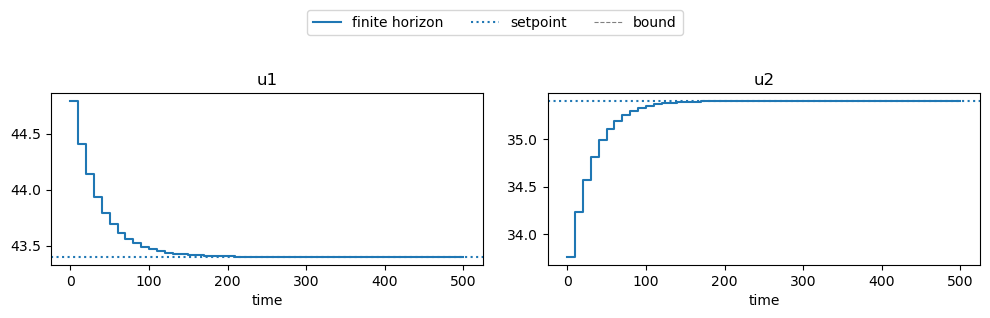

In [9]:
plot_controls(m2, t_max=500);

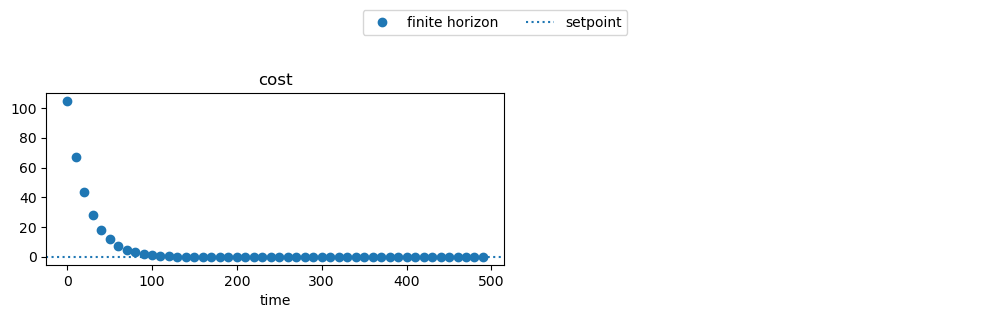

In [10]:
plot_stage_cost(m2, t_max=500);